In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. CHARGEMENT DES DONNÉES
df = pd.read_csv('../data/clean_data.csv', encoding='ISO-8859-1')

In [2]:
#  KPI  : RÉTENTION & CHURN

# 1. PREMIÈRE ET DERNIÈRE COMMANDE PAR CLIENT
client_dates = df.groupby('CustomerID').agg(
    premiere_commande=('InvoiceDate', 'min'),
    derniere_commande=('InvoiceDate', 'max'),
    nb_commandes=('InvoiceNo', 'nunique'),
    ca_total=('CA', 'sum')
)

print(" PROFIL CLIENTS")
print(f"Total clients       : {len(client_dates)}")
print(f"Clients 1 commande  : {(client_dates['nb_commandes'] == 1).sum()}")
print(f"Clients récurrents  : {(client_dates['nb_commandes'] > 1).sum()}")


 PROFIL CLIENTS
Total clients       : 4338
Clients 1 commande  : 1493
Clients récurrents  : 2845



 RÉTENTION vs CHURN
 Taux de Rétention : 65.6%
 Taux de Churn     : 34.4%
   → 1493 clients n'ont JAMAIS racheté
   → 2845 clients sont REVENUS


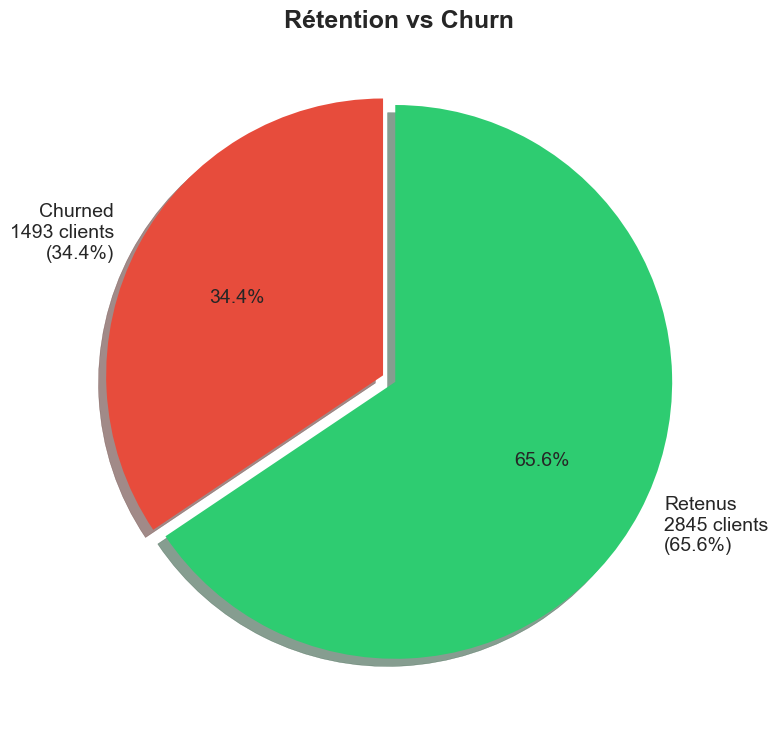

In [6]:
# 2. TAUX DE RÉTENTION SIMPLE

clients_une_fois = (client_dates['nb_commandes'] == 1).sum()
clients_recurrents = (client_dates['nb_commandes'] > 1).sum()
total_clients = len(client_dates)

taux_retention = (clients_recurrents / total_clients) * 100
taux_churn = (clients_une_fois / total_clients) * 100

print("\n RÉTENTION vs CHURN")
print(f" Taux de Rétention : {taux_retention:.1f}%")
print(f" Taux de Churn     : {taux_churn:.1f}%")
print(f"   → {clients_une_fois} clients n'ont JAMAIS racheté")
print(f"   → {clients_recurrents} clients sont REVENUS")

# Visualisation
plt.figure(figsize=(8, 8))
labels = [f'Churned\n{clients_une_fois} clients\n({taux_churn:.1f}%)', 
          f'Retenus\n{clients_recurrents} clients\n({taux_retention:.1f}%)']
sizes = [clients_une_fois, clients_recurrents]
colors = ['#e74c3c', '#2ecc71']
explode = (0.05, 0)

plt.pie(sizes, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', textprops={'fontsize': 14},
        shadow=True, startangle=90)
plt.title(' Rétention vs Churn', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()
